# 01 — Data Exploration: does the synthetic data behave like a real distributor?

**Purpose.** Before any analysis, verify that the generated data (Phase 2) exhibits
the business patterns it is supposed to — *at realistic levels, with overlap and
noise* — and that it is internally consistent.

**Two kinds of data are used here, deliberately kept apart:**

| Source | Folder | Used for |
|---|---|---|
| Raw operational tables (what an ERP would export) | `data/raw/` | Everything an analyst would do |
| Generator answer key (intended pattern, supplier archetype) | `data/synthetic_truth/` | **Validation only** — checking the generator did what it claims |

The answer key never feeds the analytical phases. Sections that use it are marked
🔍 *validation only*.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.config import get_config
from src.data_generation import generate_dataset
from src.data_validation import run_all_checks

paths = get_config().paths
if not (paths.raw_data_dir / "demand_monthly.csv").exists():
    generate_dataset().save(paths)  # reproducible from seed 42

def load(folder, name, dates=()):
    return pd.read_csv(folder / f"{name}.csv", parse_dates=list(dates))

suppliers = load(paths.raw_data_dir, "suppliers")
products = load(paths.raw_data_dir, "products", ["launch_date"])
demand = load(paths.raw_data_dir, "demand_monthly", ["month_start"])
inventory = load(paths.raw_data_dir, "inventory_snapshot", ["month_end"])
pos = load(paths.raw_data_dir, "purchase_orders", ["order_date", "promised_date"])
receipts = load(paths.raw_data_dir, "supplier_deliveries", ["receipt_date"])
AS_OF = inventory["month_end"].max()

# Chart style: validated palette slots 1-2, recessive axes, one y-axis per chart.
BLUE, ORANGE, INK, MUTED = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e"
plt.rcParams.update({
    "figure.figsize": (8, 3.6), "figure.dpi": 110, "axes.spines.top": False,
    "axes.spines.right": False, "axes.edgecolor": "#c9c8c2", "axes.grid": True,
    "grid.color": "#ecebe7", "axes.axisbelow": True, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.labelcolor": MUTED, "xtick.color": MUTED,
    "ytick.color": MUTED, "lines.linewidth": 2, "font.size": 9,
})
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
print(f"As-of date: {AS_OF.date()}")

As-of date: 2025-12-31


## 1. Tables and row counts

In [2]:
tables = {
    "suppliers": suppliers, "products": products, "demand_monthly": demand,
    "inventory_snapshot": inventory, "purchase_orders": pos, "supplier_deliveries": receipts,
}
pd.DataFrame({
    "rows": {k: len(v) for k, v in tables.items()},
    "columns": {k: ", ".join(v.columns) for k, v in tables.items()},
})

,rows,columns
suppliers,50,"supplier_id, supplier_name, region, quoted_lea..."
products,5000,"sku_id, category, supplier_id, unit_cost, unit..."
demand_monthly,114424,"sku_id, month_start, ordered_qty, shipped_qty"
inventory_snapshot,114424,"sku_id, month_end, on_hand_qty, allocated_qty"
purchase_orders,35684,"po_line_id, po_number, sku_id, supplier_id, or..."
supplier_deliveries,36907,"receipt_id, po_line_id, receipt_date, received..."


`demand_monthly` and `inventory_snapshot` have fewer than 5,000 × 24 = 120,000 rows
because products launched during the window only have rows from their launch month.

## 2. Data-quality report

In [3]:
dq = run_all_checks(tables, AS_OF)
dq[["check", "table", "severity", "status", "failed_rows", "total_rows"]]

,check,table,severity,status,failed_rows,total_rows
0,duplicate_records,suppliers,ERROR,PASS,0,50
1,duplicate_records,products,ERROR,PASS,0,5000
2,duplicate_records,demand_monthly,ERROR,PASS,0,114424
3,duplicate_records,inventory_snapshot,ERROR,PASS,0,114424
4,duplicate_records,purchase_orders,ERROR,PASS,0,35684
5,duplicate_records,supplier_deliveries,ERROR,PASS,0,36907
6,missing_values,suppliers,ERROR,PASS,0,50
7,missing_values,products,ERROR,PASS,0,5000
8,missing_values,demand_monthly,ERROR,PASS,0,114424
9,missing_values,inventory_snapshot,ERROR,PASS,0,114424


## 3. Customer demand vs. shipments

Demand is what customers **ordered**; shipments are what we **could deliver**.
The gap is lost sales caused by stockouts — the data model keeps them separate so
forecasts are not trained on stockout-censored shipments.

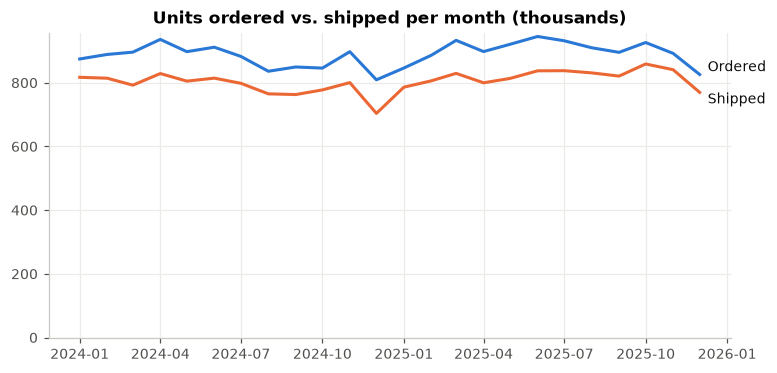

Unit fill rate: 90.5%   SKU-months with a shortfall: 10.2%


In [4]:
monthly = demand.groupby("month_start")[["ordered_qty", "shipped_qty"]].sum()
fig, ax = plt.subplots()
ax.plot(monthly.index, monthly["ordered_qty"] / 1e3, color=BLUE)
ax.plot(monthly.index, monthly["shipped_qty"] / 1e3, color=ORANGE)
ax.text(monthly.index[-1], monthly["ordered_qty"].iloc[-1] / 1e3, "  Ordered", color=INK, va="bottom")
ax.text(monthly.index[-1], monthly["shipped_qty"].iloc[-1] / 1e3, "  Shipped", color=INK, va="top")
ax.set_title("Units ordered vs. shipped per month (thousands)")
ax.set_ylim(0, None)
plt.show()

fill = demand["shipped_qty"].sum() / demand["ordered_qty"].sum()
short = (demand["shipped_qty"] < demand["ordered_qty"]).mean()
print(f"Unit fill rate: {fill:.1%}   SKU-months with a shortfall: {short:.1%}")

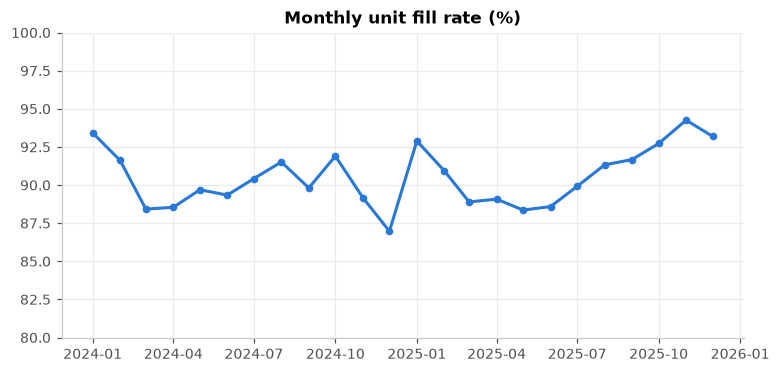

In [5]:
fill_month = monthly["shipped_qty"] / monthly["ordered_qty"]
fig, ax = plt.subplots()
ax.plot(fill_month.index, fill_month * 100, color=BLUE, marker="o", markersize=4)
ax.set_title("Monthly unit fill rate (%)")
ax.set_ylim(80, 100)
plt.show()

## 4. Value concentration (emerges, not assigned)

No ABC class exists in the data. Unit cost and volume are drawn from log-normal
distributions with a loose negative correlation; any Pareto shape must *emerge*.
ABC classification itself happens in Phase 4.

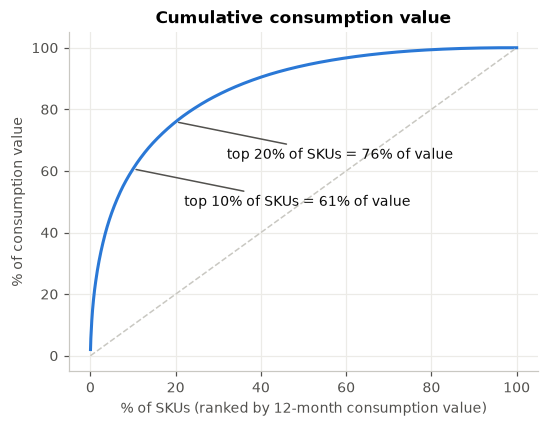

SKUs needed for 80% of value: 24.0%


In [6]:
last12 = demand[demand["month_start"] > AS_OF - pd.DateOffset(months=12)]
usage = last12.groupby("sku_id")["ordered_qty"].sum()
value = (usage * products.set_index("sku_id")["unit_cost"]).dropna().sort_values(ascending=False)
cum = value.cumsum() / value.sum()
sku_share = np.arange(1, len(cum) + 1) / len(cum)

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(sku_share * 100, cum.values * 100, color=BLUE)
ax.plot([0, 100], [0, 100], color="#c9c8c2", linewidth=1, linestyle="--")
for p in (0.1, 0.2):
    y = cum.iloc[int(len(cum) * p) - 1]
    ax.annotate(f"top {p:.0%} of SKUs = {y:.0%} of value", (p * 100, y * 100),
                xytext=(p * 100 + 12, y * 100 - 12), color=INK,
                arrowprops=dict(arrowstyle="-", color=MUTED))
ax.set_xlabel("% of SKUs (ranked by 12-month consumption value)")
ax.set_ylabel("% of consumption value")
ax.set_title("Cumulative consumption value")
plt.show()
print("SKUs needed for 80% of value:", f"{(cum < 0.80).mean() + 1/len(cum):.1%}")

## 5. Demand patterns 🔍 *validation only*

Does each intended pattern show up in the observed data — and do the patterns
**overlap**, as real demand does?

In [7]:
truth = pd.read_csv(paths.synthetic_truth_dir / "sku_generation_truth.csv")
pattern = truth.set_index("sku_id")["intended_pattern"]

full = demand[demand.groupby("sku_id")["month_start"].transform("count") == 24]
stats = full.groupby("sku_id")["ordered_qty"].agg(["mean", "std"])
stats["cv"] = stats["std"] / stats["mean"].replace(0, np.nan)
stats["zero_months"] = full.assign(z=full["ordered_qty"].eq(0)).groupby("sku_id")["z"].mean()
yearly = full.assign(y=full["month_start"].dt.year).pivot_table(
    index="sku_id", columns="y", values="ordered_qty", aggfunc="sum")
stats["yoy_growth"] = (yearly[2025] + 1) / (yearly[2024] + 1) - 1
stats = stats.join(pattern)

summary = stats.groupby("intended_pattern").agg(
    skus=("cv", "size"),
    cv_p25=("cv", lambda s: s.quantile(0.25)), cv_median=("cv", "median"),
    cv_p75=("cv", lambda s: s.quantile(0.75)),
    zero_month_share=("zero_months", "median"), yoy_growth_median=("yoy_growth", "median"),
)
summary.sort_values("cv_median")

,skus,cv_p25,cv_median,cv_p75,zero_month_share,yoy_growth_median
intended_pattern,,,,,,
STABLE,1528,0.298,0.403,0.570,0.000,-0.007
TRENDING_UP,553,0.368,0.460,0.584,0.000,0.460
SEASONAL,715,0.473,0.587,0.730,0.000,0.004
DECLINING,520,0.482,0.611,0.796,0.000,-0.422
HIGHLY_VARIABLE,547,0.992,1.140,1.297,0.042,0.000
END_OF_LIFE,224,0.904,1.337,1.773,0.500,-0.961
INTERMITTENT,612,1.283,1.587,2.066,0.625,-0.060


Read across a row: each pattern has the expected signature (intermittent SKUs have many
zero months, trending SKUs grow, declining SKUs shrink), but the CV ranges **overlap**
between patterns — so XYZ classification in Phase 4 will not simply reproduce the
generator's labels.

In [8]:
# Share of each intended pattern that a textbook CV rule would put in X / Y / Z.
xyz = pd.cut(stats["cv"], [-np.inf, 0.5, 1.0, np.inf], labels=["X (CV<=0.5)", "Y", "Z (CV>1)"])
pd.crosstab(stats["intended_pattern"], xyz, normalize="index").round(2)

cv,X (CV<=0.5),Y,Z (CV>1)
intended_pattern,,,
DECLINING,0.300,0.590,0.110
END_OF_LIFE,0.000,0.310,0.690
HIGHLY_VARIABLE,0.000,0.270,0.730
INTERMITTENT,0.000,0.040,0.960
SEASONAL,0.300,0.620,0.070
STABLE,0.670,0.300,0.020
TRENDING_UP,0.590,0.370,0.040


### Seasonality

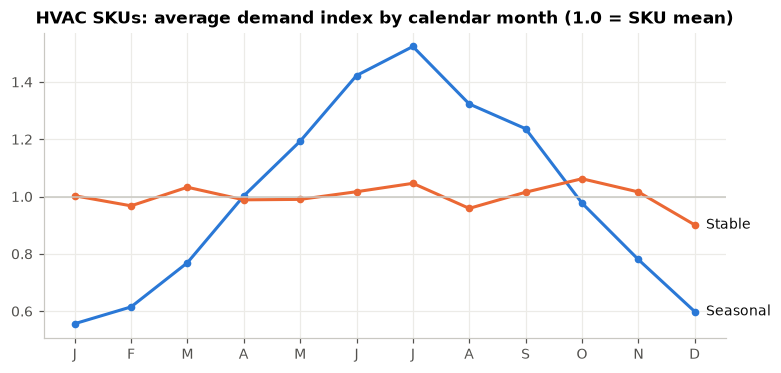

In [9]:
d = full.join(pattern, on="sku_id")
d["index"] = d["ordered_qty"] / d.groupby("sku_id")["ordered_qty"].transform("mean")
d["month"] = d["month_start"].dt.month
hvac = products.set_index("sku_id")["category"].eq("HVAC & Climate")
prof = d[d["sku_id"].map(hvac)].groupby(["intended_pattern", "month"])["index"].mean().unstack(0)

fig, ax = plt.subplots()
ax.plot(prof.index, prof["SEASONAL"], color=BLUE, marker="o", markersize=4)
ax.plot(prof.index, prof["STABLE"], color=ORANGE, marker="o", markersize=4)
ax.text(12.2, prof["SEASONAL"].iloc[-1], "Seasonal", color=INK, va="center")
ax.text(12.2, prof["STABLE"].iloc[-1], "Stable", color=INK, va="center")
ax.axhline(1, color="#c9c8c2", linewidth=1)
ax.set_xticks(range(1, 13), ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
ax.set_title("HVAC SKUs: average demand index by calendar month (1.0 = SKU mean)")
plt.show()

Seasonal HVAC items peak in summer; stable HVAC items still show a mild summer lift
and the December working-day dip — every SKU carries some seasonality, as in reality.

## 6. Supplier behaviour

In [10]:
lines = pos.merge(
    receipts.groupby("po_line_id").agg(received=("received_qty", "sum"),
                                        last_receipt=("receipt_date", "max"),
                                        first_receipt=("receipt_date", "min"),
                                        n_receipts=("receipt_id", "count")),
    on="po_line_id", how="left")
closed = lines[lines["status"] == "CLOSED"].copy()
closed["on_time_full"] = closed["last_receipt"] <= closed["promised_date"]
closed["lead_time_days"] = (closed["last_receipt"] - closed["order_date"]).dt.days
closed["days_late"] = (closed["last_receipt"] - closed["promised_date"]).dt.days.clip(lower=0)

print("PO line status as of", AS_OF.date())
print(pos["status"].value_counts().to_string())
print(f"\nLines with split receipts: {(lines['n_receipts'] > 1).mean():.1%}   "
      f"first receipt after promised date: {(lines['first_receipt'] > lines['promised_date']).mean():.1%}")

PO line status as of 2025-12-31
status
CLOSED                34253
CLOSED_SHORT            704
OPEN                    623
PARTIALLY_RECEIVED      104

Lines with split receipts: 5.2%   first receipt after promised date: 14.6%


In [11]:
# 🔍 validation only: does the hidden archetype drive observable performance?
supplier_truth = pd.read_csv(paths.synthetic_truth_dir / "supplier_generation_truth.csv")
by_sup = closed.groupby("supplier_id").agg(
    lines=("po_line_id", "size"), on_time_full=("on_time_full", "mean"),
    lead_time_days=("lead_time_days", "mean"), lead_time_std=("lead_time_days", "std"),
    avg_days_late=("days_late", "mean"),
).join(supplier_truth.set_index("supplier_id")["archetype"])
by_type = by_sup.groupby("archetype").agg(
    suppliers=("lines", "size"), on_time_min=("on_time_full", "min"),
    on_time_median=("on_time_full", "median"), on_time_max=("on_time_full", "max"),
    lead_time_median=("lead_time_days", "median"), lead_time_std_median=("lead_time_std", "median"),
)
by_type

,suppliers,on_time_min,on_time_median,on_time_max,lead_time_median,lead_time_std_median
archetype,,,,,,
DOMESTIC_RELIABLE,18,0.714,0.946,0.988,17.241,4.487
DOMESTIC_STANDARD,14,0.621,0.848,1.000,28.561,7.012
IMPORT_LONG_LEAD,10,0.468,0.767,0.946,83.330,9.553
UNRELIABLE,8,0.295,0.542,0.731,52.712,15.023


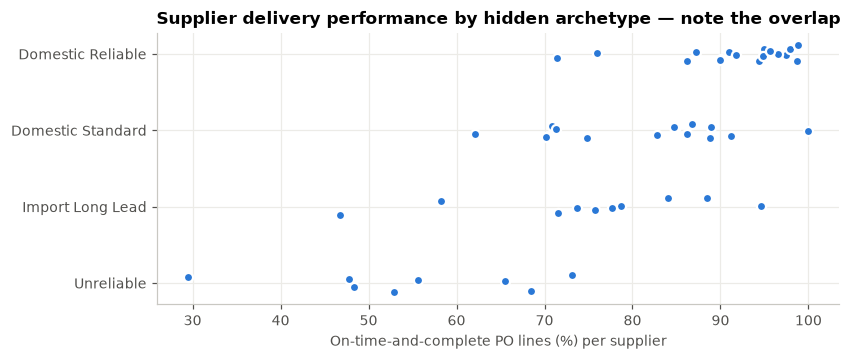

In [12]:
order = by_sup.groupby("archetype")["on_time_full"].median().sort_values().index
fig, ax = plt.subplots(figsize=(8, 3.2))
for i, arch in enumerate(order):
    vals = by_sup.loc[by_sup["archetype"] == arch, "on_time_full"] * 100
    ax.scatter(vals, np.full(len(vals), i) + np.random.default_rng(i).uniform(-0.12, 0.12, len(vals)),
               s=36, color=BLUE, edgecolor="white", linewidth=1.5, zorder=3)
ax.set_yticks(range(len(order)), [a.replace("_", " ").title() for a in order])
ax.set_xlabel("On-time-and-complete PO lines (%) per supplier")
ax.set_title("Supplier delivery performance by hidden archetype — note the overlap")
plt.show()

## 7. Inventory health signals at the as-of date

In [13]:
snap = inventory[inventory["month_end"] == AS_OF].merge(products, on="sku_id")
avg12 = last12.groupby("sku_id")["ordered_qty"].mean()
sum6 = demand[demand["month_start"] > AS_OF - pd.DateOffset(months=6)].groupby("sku_id")["ordered_qty"].sum()
snap["avg12"] = snap["sku_id"].map(avg12)
snap["sum6"] = snap["sku_id"].map(sum6)
snap["value"] = snap["on_hand_qty"] * snap["unit_cost"]
snap["months_of_supply"] = snap["on_hand_qty"] / snap["avg12"].replace(0, np.nan)
total = snap["value"].sum()

open_po = lines[lines["status"].isin(["OPEN", "PARTIALLY_RECEIVED"])]
open_qty = (open_po["ordered_qty"] - open_po["received"].fillna(0))
signals = pd.Series({
    "Inventory value at cost ($M)": total / 1e6,
    "Open PO value ($M)": (open_qty * open_po["unit_price"]).sum() / 1e6,
    "SKUs out of stock": int((snap["on_hand_qty"] == 0).sum()),
    "Median months of supply (active SKUs)": snap["months_of_supply"].median(),
    "Value share > 6 months of supply": snap.loc[snap["months_of_supply"] > 6, "value"].sum() / total,
    "SKUs with stock but no demand in 6 months": int(((snap["on_hand_qty"] > 0) & (snap["sum6"] == 0)).sum()),
    "Value share of those (dead-stock candidates)": snap.loc[(snap["on_hand_qty"] > 0) & (snap["sum6"] == 0), "value"].sum() / total,
    "Slow movers (<=5 units/month) with MOQ >= 6 months of demand": int(((snap["avg12"] > 0) & (snap["avg12"] <= 5) & (snap["moq"] >= 6 * snap["avg12"])).sum()),
})
signals.to_frame("value")

,value
Inventory value at cost ($M),17.292
Open PO value ($M),2.205
SKUs out of stock,172.000
Median months of supply (active SKUs),2.934
Value share > 6 months of supply,0.236
SKUs with stock but no demand in 6 months,238.000
Value share of those (dead-stock candidates),0.056
Slow movers (<=5 units/month) with MOQ >= 6 months of demand,226.000


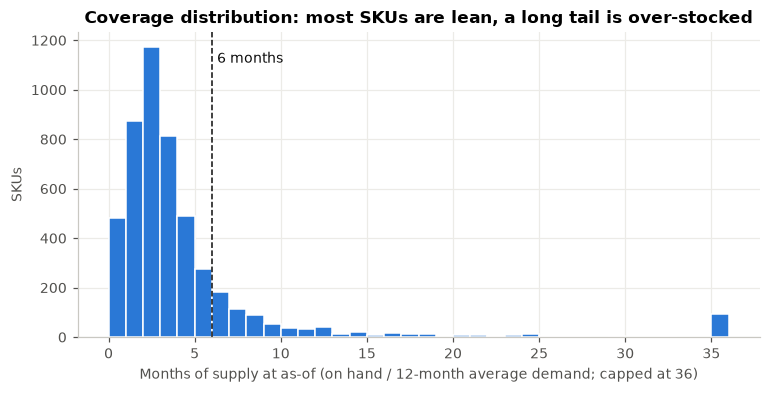

In [14]:
mos = snap["months_of_supply"].dropna().clip(upper=36)
fig, ax = plt.subplots()
ax.hist(mos, bins=np.arange(0, 37, 1), color=BLUE, edgecolor="white", linewidth=1)
ax.axvline(6, color=INK, linewidth=1, linestyle="--")
ax.text(6.3, ax.get_ylim()[1] * 0.9, "6 months", color=INK)
ax.set_xlabel("Months of supply at as-of (on hand / 12-month average demand; capped at 36)")
ax.set_ylabel("SKUs")
ax.set_title("Coverage distribution: most SKUs are lean, a long tail is over-stocked")
plt.show()

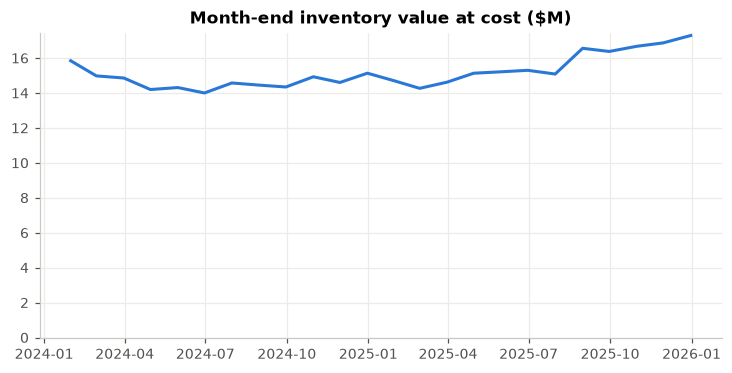

Inventory turns (12m COGS / average inventory): 3.6   DIO: 101 days


In [15]:
value_trend = inventory.merge(products[["sku_id", "unit_cost"]], on="sku_id")
value_trend = (value_trend["on_hand_qty"] * value_trend["unit_cost"]).groupby(value_trend["month_end"]).sum()
fig, ax = plt.subplots()
ax.plot(value_trend.index, value_trend / 1e6, color=BLUE)
ax.set_ylim(0, None)
ax.set_title("Month-end inventory value at cost ($M)")
plt.show()

cogs = (last12["shipped_qty"] * last12["sku_id"].map(products.set_index("sku_id")["unit_cost"])).sum()
avg_inv = value_trend[value_trend.index > AS_OF - pd.DateOffset(months=12)].mean()
print(f"Inventory turns (12m COGS / average inventory): {cogs / avg_inv:.1f}   DIO: {365 / (cogs / avg_inv):.0f} days")

## 8. Internal consistency

In [16]:
rcv = receipts.merge(pos[["po_line_id", "sku_id"]], on="po_line_id")
rcv["month_start"] = rcv["receipt_date"].dt.to_period("M").dt.start_time
monthly_rcv = rcv.groupby(["sku_id", "month_start"])["received_qty"].sum()
flow = inventory.assign(month_start=inventory["month_end"].dt.to_period("M").dt.start_time)
flow = flow.merge(demand, on=["sku_id", "month_start"]).sort_values(["sku_id", "month_start"])
flow["receipts"] = flow.set_index(["sku_id", "month_start"]).index.map(monthly_rcv).fillna(0)
flow["prev"] = flow.groupby("sku_id")["on_hand_qty"].shift()
chk = flow.dropna(subset=["prev"])
balance_ok = (chk["prev"] + chk["receipts"] - chk["shipped_qty"] == chk["on_hand_qty"]).mean()

consistency = pd.Series({
    "Stock balance reconciles (opening + receipts - shipped = closing)": balance_ok,
    "Shipped <= ordered": (demand["shipped_qty"] <= demand["ordered_qty"]).mean(),
    "Receipts on/after order date": (lines["first_receipt"].dropna() > lines.loc[lines["first_receipt"].notna(), "order_date"]).mean(),
    "Received <= ordered per PO line": (lines["received"].fillna(0) <= lines["ordered_qty"]).mean(),
    "Allocated <= on hand": (inventory["allocated_qty"] <= inventory["on_hand_qty"]).mean(),
})
consistency.to_frame("share of rows passing")

,share of rows passing
Stock balance reconciles (opening + receipts - shipped = closing),1.000
Shipped <= ordered,1.000
Receipts on/after order date,1.000
Received <= ordered per PO line,1.000
Allocated <= on hand,1.000


## 9. Conclusions

The tables above are generated from seed 42 and are regenerated identically by
`python -m src.pipeline`. What they show:

* **Service problem is real but not absurd.** Unit fill rate sits in the low 90s with
  a meaningful minority of SKU-months short — the "stockouts on important items"
  complaint is visible without the business looking broken.
* **Value concentration emerges** from cost and volume distributions; ABC analysis in
  Phase 4 has a real Pareto shape to find.
* **Patterns overlap.** Each intended pattern has its signature, but CV ranges overlap,
  so segmentation will be imperfect — as in real data.
* **Supplier archetypes drive but do not determine performance** — the best unreliable
  supplier beats the worst standard one.
* **Working-capital problem is visible**: a long tail of over-stocked SKUs, dead-stock
  candidates, and slow movers whose MOQ alone covers many months of demand.
* **Stock flow reconciles exactly**, so every downstream metric can be traced back to
  demand, receipts and shipments.